## 1. Importy

In [3]:
import os
import copy
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Urządzenie: {DEVICE}')

Urządzenie: cuda


## 2. Konfiguracja ścieżek

In [4]:
# ====
# ============================================================
ROOT = Path('C:/Users/julia/OneDrive/Pulpit/systemy_wizyjne/projekt1/cable-20260329T130118Z-1-001/cable')

TRAIN_DIR  = ROOT / 'train'
TEST_DIR   = ROOT / 'test'
GT_DIR     = ROOT / 'ground_truth'

IMG_SIZE   = 224
BATCH_SIZE = 16
NUM_EPOCHS = 40
LR         = 1e-4
PATIENCE   = 8

# Sprawdź że ścieżki istnieją
for p in [TRAIN_DIR, TEST_DIR]:
    assert p.exists(), f'Nie znaleziono folderu: {p}'
print('Ścieżki OK.')

Ścieżki OK.


## 3. Eksploracja struktury danych

In [5]:
# Zbadaj wszystkie klasy w test/
test_classes = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()])
print(f'Klasy w test/: {test_classes}')

# Zlicz obrazy
exts = ('*.jpg', '*.jpeg', '*.png', '*.bmp')

def count_images(folder):
    return sum(len(list(folder.glob(e))) for e in exts)

train_good_n = count_images(TRAIN_DIR / 'good')
print(f'\ntrain/good: {train_good_n} obrazów')
print()

counts = {}
for cls in test_classes:
    n = count_images(TEST_DIR / cls)
    counts[cls] = n
    print(f'  test/{cls:<25} {n:>3} obrazów')

print(f'\nŁącznie w test/: {sum(counts.values())} obrazów')

Klasy w test/: ['bent_wire', 'cable_swap', 'combined', 'cut_inner_insulation', 'cut_outer_insulation', 'good', 'missing_cable', 'missing_wire', 'poke_insulation']

train/good: 224 obrazów

  test/bent_wire                  12 obrazów
  test/cable_swap                 11 obrazów
  test/combined                   10 obrazów
  test/cut_inner_insulation       13 obrazów
  test/cut_outer_insulation        9 obrazów
  test/good                       46 obrazów
  test/missing_cable              11 obrazów
  test/missing_wire                9 obrazów
  test/poke_insulation             9 obrazów

Łącznie w test/: 130 obrazów


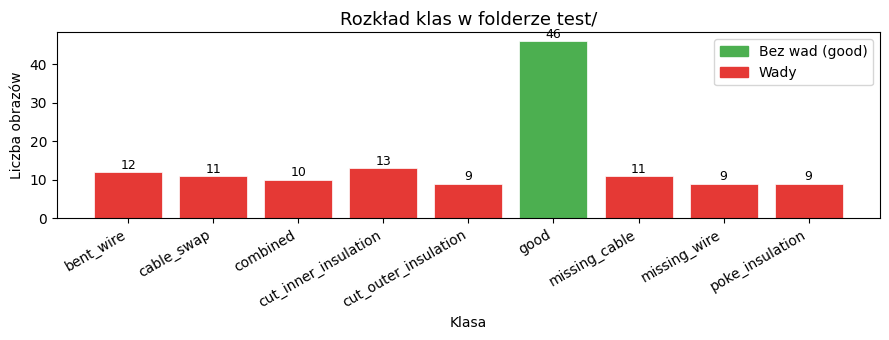

In [6]:
# Wykres rozkładu klas testowych
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ['#4CAF50' if c == 'good' else '#E53935' for c in counts.keys()]
bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Rozkład klas w folderze test/', fontsize=13)
ax.set_ylabel('Liczba obrazów')
ax.set_xlabel('Klasa')
plt.xticks(rotation=30, ha='right')
good_patch = mpatches.Patch(color='#4CAF50', label='Bez wad (good)')
bad_patch  = mpatches.Patch(color='#E53935', label='Wady')
ax.legend(handles=[good_patch, bad_patch])
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, str(int(h)),
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

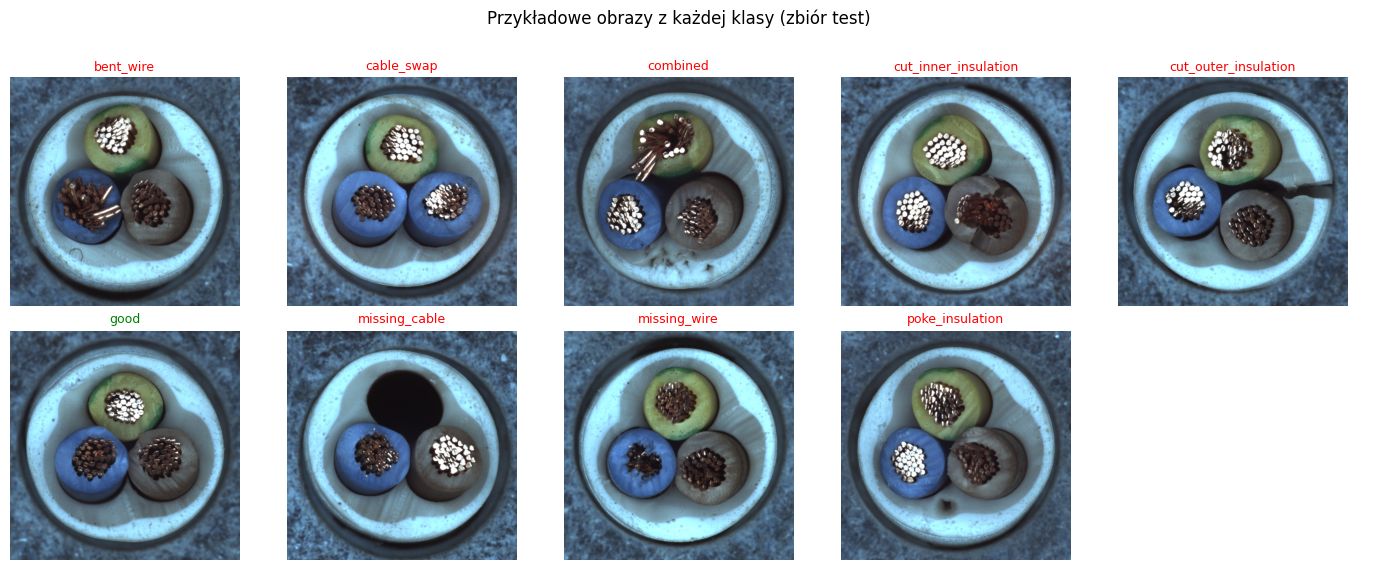

In [7]:
# Podgląd przykładowych obrazów z każdej klasy testowej
n_cls = len(test_classes)
cols = min(5, n_cls)
rows = (n_cls + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.8, rows * 2.8))
axes = np.array(axes).flatten()

for i, cls in enumerate(test_classes):
    imgs = []
    for e in exts:
        imgs.extend(list((TEST_DIR / cls).glob(e)))
    if not imgs:
        continue
    img = Image.open(imgs[0]).convert('RGB')
    color = 'green' if cls == 'good' else 'red'
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9, color=color)
    axes[i].axis('off')

for ax in axes[n_cls:]:
    ax.axis('off')

plt.suptitle('Przykładowe obrazy z każdej klasy (zbiór test)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('class_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Budowanie datasetów

**Strategia:**
- **Train**: obrazy z `train/good/` + **uzupełnienie** obrazami `test/good/` (żeby mieć wystarczająco danych)
- **Walidacja**: 20% ze zbioru treningowego (wydzielone losowo)
- **Test**: wszystkie klasy z `test/` (dobry + wady)

standardowe postępowanie przy małych zbiorach anomaly-detection.

In [8]:
# Zbuduj tymczasową strukturę folderów kompatybilną z ImageFolder
# Potrzebna bo train/ ma tylko 'good', a musimy mieć wszystkie klasy w jednym miejscu

TEMP_TRAIN = Path('./temp_train_dataset')
TEMP_TEST  = Path('./temp_test_dataset')

# Usuń jeśli istnieje (restart)
if TEMP_TRAIN.exists(): shutil.rmtree(TEMP_TRAIN)
if TEMP_TEST.exists():  shutil.rmtree(TEMP_TEST)

# Zbierz wszystkie klasy z test/
all_classes = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()])
print(f'Wszystkie klasy: {all_classes}')

# Kopiuj obrazy testowe do temp_test_dataset/
for cls in all_classes:
    src = TEST_DIR / cls
    dst = TEMP_TEST / cls
    dst.mkdir(parents=True, exist_ok=True)
    for e in exts:
        for f in src.glob(e):
            shutil.copy2(f, dst / f.name)

# Dla treningu: good z train/ + good z test/ (połącz)
(TEMP_TRAIN / 'good').mkdir(parents=True, exist_ok=True)
good_src_train = TRAIN_DIR / 'good'
good_src_test  = TEST_DIR  / 'good'
count_copied = 0
for src_dir in [good_src_train, good_src_test]:
    if src_dir.exists():
        for e in exts:
            for f in src_dir.glob(e):
                dst_name = f'{src_dir.parent.name}_{f.name}'
                shutil.copy2(f, TEMP_TRAIN / 'good' / dst_name)
                count_copied += 1

print(f'Skopiowano {count_copied} obrazów klasy "good" do treningu.')

# Skopiuj klasy wad do temp_train (potrzebne dla ImageFolder)
defect_classes = [c for c in all_classes if c != 'good']
for cls in defect_classes:
    src = TEST_DIR / cls
    dst = TEMP_TRAIN / cls
    dst.mkdir(parents=True, exist_ok=True)
    for e in exts:
        for f in src.glob(e):
            shutil.copy2(f, dst / f.name)

print('Tymczasowe foldery gotowe.')

Wszystkie klasy: ['bent_wire', 'cable_swap', 'combined', 'cut_inner_insulation', 'cut_outer_insulation', 'good', 'missing_cable', 'missing_wire', 'poke_insulation']
Skopiowano 270 obrazów klasy "good" do treningu.
Tymczasowe foldery gotowe.


In [14]:
IMG_SIZE   = 224        # rozmiar obrazu (224x224)
BATCH_SIZE = 64  

TEMP_TRAIN = r"C:\Users\julia\OneDrive\Pulpit\systemy_wizyjne\projekt1\temp_train_dataset"
TEMP_TEST  = r"C:\Users\julia\OneDrive\Pulpit\systemy_wizyjne\projekt1\temp_test_dataset"


# Transformacje
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),        # kabel ma symetrię kołową
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Wczytaj datasety
full_train_ds = datasets.ImageFolder(TEMP_TRAIN, transform=train_transforms)
test_ds       = datasets.ImageFolder(TEMP_TEST,  transform=eval_transforms)

CLASS_NAMES = test_ds.classes   # pobierz nazwy z test (kompletne)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Klasy ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Obrazy treningowe (przed podziałem): {len(full_train_ds)}')
print(f'Obrazy testowe: {len(test_ds)}')

# Wydziel walidację (20%) z pełnego train
n_val   = max(1, int(len(full_train_ds) * 0.20))
n_train = len(full_train_ds) - n_val

train_ds, val_ds = random_split(
    full_train_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# Val bez augmentacji
val_ds.dataset = copy.deepcopy(full_train_ds)
val_ds.dataset.transform = eval_transforms

print(f'\nPodział: train={n_train}, val={n_val}, test={len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('DataLoadery gotowe.')

Klasy (9): ['bent_wire', 'cable_swap', 'combined', 'cut_inner_insulation', 'cut_outer_insulation', 'good', 'missing_cable', 'missing_wire', 'poke_insulation']
Obrazy treningowe (przed podziałem): 354
Obrazy testowe: 130

Podział: train=284, val=70, test=130
DataLoadery gotowe.


## 5. Model — ResNet18 z Transfer Learning

In [15]:
def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Zamroź backbone
    for param in model.parameters():
        param.requires_grad = False
    # Nowa głowica
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

model = build_model(NUM_CLASSES)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parametry treningowe: {trainable:,} / {total:,}')

Parametry treningowe: 133,641 / 11,310,153


## 6. Trening z early stopping

In [16]:
LR         = 1e-4 

# Wagi klas — kompensuje niezbalansowanie (więcej good niż defects)
label_counts = np.zeros(NUM_CLASSES)
for _, label in full_train_ds:
    label_counts[label] += 1

class_weights = torch.tensor(
    [1.0 / max(c, 1) for c in label_counts], dtype=torch.float32
).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4
)

print('Wagi klas:')
for cls, w in zip(CLASS_NAMES, class_weights.cpu().numpy()):
    print(f'  {cls:<25} {w:.3f}')

Wagi klas:
  bent_wire                 0.963
  cable_swap                1.050
  combined                  1.155
  cut_inner_insulation      0.889
  cut_outer_insulation      1.284
  good                      0.043
  missing_cable             1.050
  missing_wire              1.284
  poke_insulation           1.284


In [17]:
NUM_EPOCHS = 50     # maksymalna liczba epok
PATIENCE   = 10

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total

# Trening
history = {'tr_loss': [], 'val_loss': [], 'tr_acc': [], 'val_acc': []}
best_val_loss, best_state = float('inf'), None
patience_ctr = 0

header = f'{"Epoka":>6} | {"Tr Loss":>8} | {"Tr Acc":>7} | {"Val Loss":>8} | {"Val Acc":>7}'
print(header)
print('-' * len(header))

for epoch in range(1, NUM_EPOCHS + 1):
    tr_l, tr_a  = train_epoch(model, train_loader, optimizer, criterion)
    vl_l, vl_a  = eval_epoch(model, val_loader, criterion)
    scheduler.step(vl_l)

    history['tr_loss'].append(tr_l)
    history['val_loss'].append(vl_l)
    history['tr_acc'].append(tr_a)
    history['val_acc'].append(vl_a)

    tag = ''
    if vl_l < best_val_loss:
        best_val_loss = vl_l
        best_state    = copy.deepcopy(model.state_dict())
        patience_ctr  = 0
        tag = ' ✓'
    else:
        patience_ctr += 1

    print(f'{epoch:>6} | {tr_l:>8.4f} | {tr_a*100:>6.1f}% | {vl_l:>8.4f} | {vl_a*100:>6.1f}%{tag}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping po epoce {epoch}.')
        break

model.load_state_dict(best_state)
torch.save(model.state_dict(), 'best_model_bacle.pth')
print('\nModel zapisany: best_model_bacle.pth')

 Epoka |  Tr Loss |  Tr Acc | Val Loss | Val Acc
------------------------------------------------
     1 |   2.3026 |   12.1% |   2.1789 |   15.7% ✓
     2 |   2.2109 |   10.2% |   2.1964 |   18.6%
     3 |   2.1688 |   17.6% |   2.2109 |   12.9%
     4 |   2.1243 |   13.3% |   2.2224 |   10.0%
     5 |   2.2689 |   13.3% |   2.2259 |    8.6%
     6 |   2.1068 |   15.2% |   2.2292 |    7.1%
     7 |   2.1863 |   12.5% |   2.2299 |    7.1%
     8 |   2.1410 |   11.3% |   2.2294 |    5.7%
     9 |   2.1824 |   10.5% |   2.2315 |    4.3%
    10 |   2.1938 |   10.5% |   2.2253 |    4.3%
    11 |   2.0913 |   11.3% |   2.2211 |    2.9%

Early stopping po epoce 11.

Model zapisany: best_model_bacle.pth


## 7. Krzywe uczenia

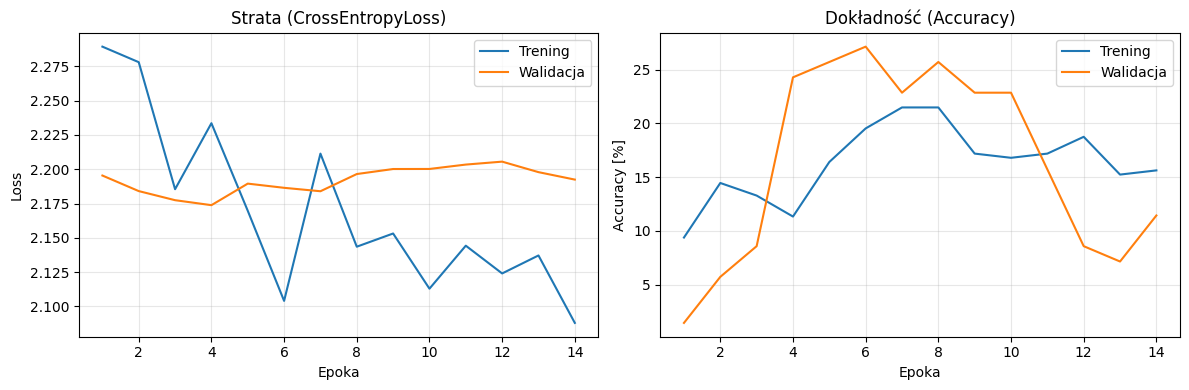

In [12]:
ep = range(1, len(history['tr_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep, history['tr_loss'],  label='Trening')
ax1.plot(ep, history['val_loss'], label='Walidacja')
ax1.set_title('Strata (CrossEntropyLoss)')
ax1.set_xlabel('Epoka'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, [a*100 for a in history['tr_acc']],  label='Trening')
ax2.plot(ep, [a*100 for a in history['val_acc']], label='Walidacja')
ax2.set_title('Dokładność (Accuracy)')
ax2.set_xlabel('Epoka'); ax2.set_ylabel('Accuracy [%]')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 8. Ewaluacja na zbiorze testowym

In [13]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for imgs, labels in loader:
        out = model(imgs.to(DEVICE))
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = predict_all(model, test_loader)

print(f'Test Accuracy  : {accuracy_score(y_true, y_pred)*100:.2f}%')
print(f'Test F1 (macro): {f1_score(y_true, y_pred, average="macro"):.4f}')
print(f'Test F1 (weighted): {f1_score(y_true, y_pred, average="weighted"):.4f}')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Test Accuracy  : 22.31%
Test F1 (macro): 0.1508
Test F1 (weighted): 0.2134

                      precision    recall  f1-score   support

           bent_wire       0.00      0.00      0.00        12
          cable_swap       0.00      0.00      0.00        11
            combined       0.00      0.00      0.00        10
cut_inner_insulation       0.11      0.15      0.13        13
cut_outer_insulation       0.14      0.11      0.12         9
                good       0.54      0.30      0.39        46
       missing_cable       1.00      0.18      0.31        11
        missing_wire       0.13      1.00      0.23         9
     poke_insulation       0.50      0.11      0.18         9

            accuracy                           0.22       130
           macro avg       0.27      0.21      0.15       130
        weighted avg       0.34      0.22      0.21       130



c:\Users\julia\OneDrive\Pulpit\systemy_wizyjne\projekt1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\julia\OneDrive\Pulpit\systemy_wizyjne\projekt1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\julia\OneDrive\Pulpit\systemy_wizyjne\projekt1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

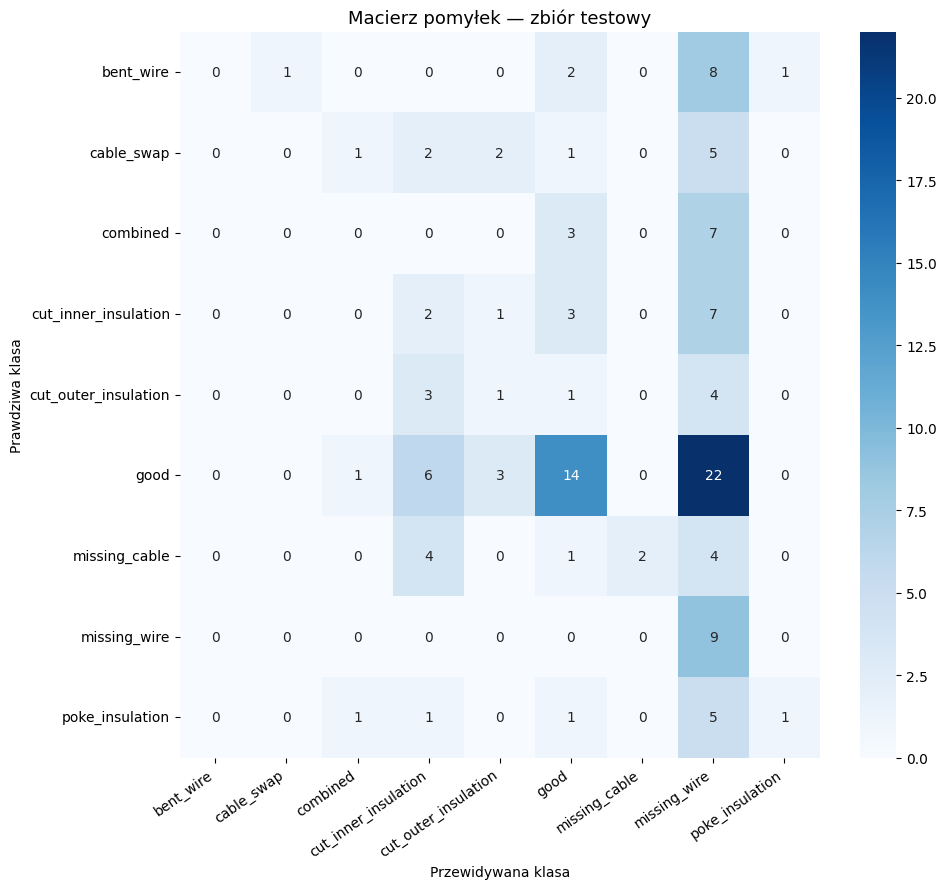

In [14]:
# Macierz pomyłek
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(6, NUM_CLASSES + 1), max(5, NUM_CLASSES)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
)
ax.set_title('Macierz pomyłek — zbiór testowy', fontsize=13)
ax.set_ylabel('Prawdziwa klasa')
ax.set_xlabel('Przewidywana klasa')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 9. Analiza błędów z maskami ground_truth

Klasy z ground_truth: ['bent_wire', 'cable_swap', 'combined', 'cut_inner_insulation', 'cut_outer_insulation', 'missing_cable', 'missing_wire', 'poke_insulation']


TypeError: unsupported operand type(s) for /: 'str' and 'str'

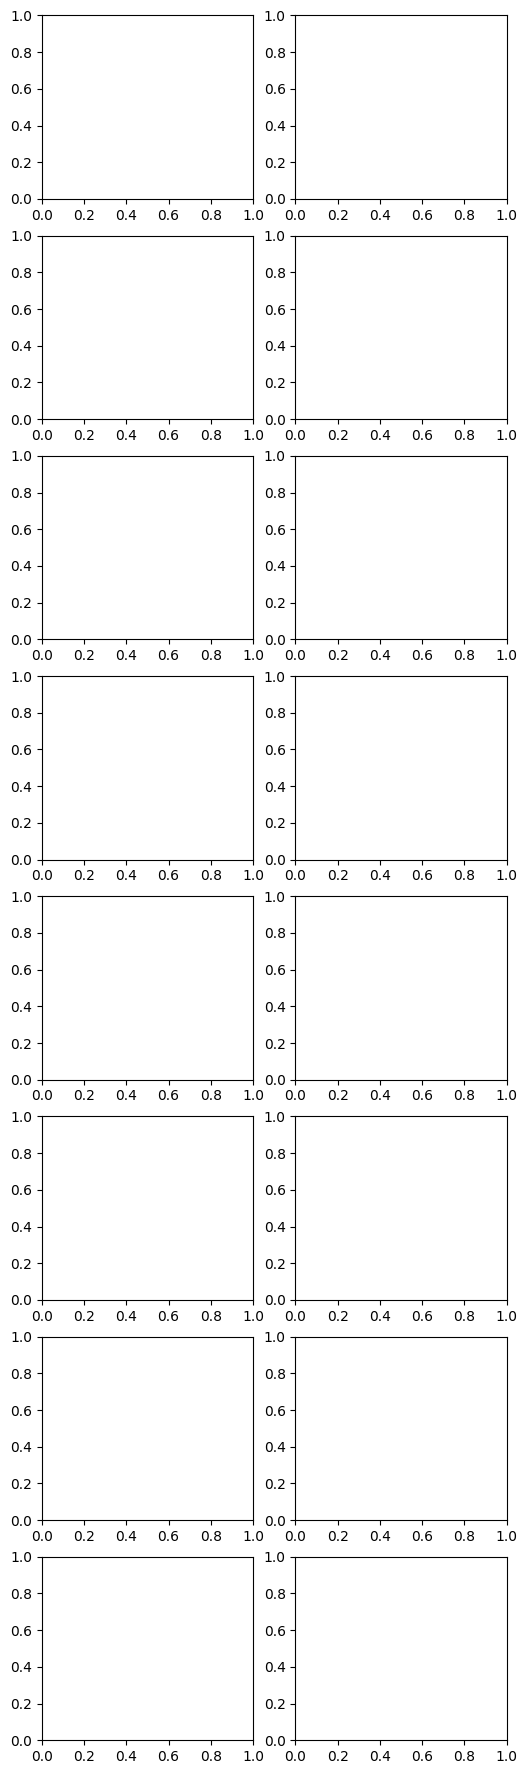

In [19]:
# Porównaj obraz z wykrytą wadą + maskę z ground_truth
# Działa jeśli folder ground_truth/ istnieje

GT_DIR     = Path(r"C:\Users\julia\OneDrive\Pulpit\systemy_wizyjne\projekt1\cable-20260329T130118Z-1-001\cable\ground_truth")
exts = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
TEST_DIR = r"C:\Users\julia\OneDrive\Pulpit\systemy_wizyjne\projekt1\temp_test_dataset"

if GT_DIR.exists():
    gt_classes = sorted([d.name for d in GT_DIR.iterdir() if d.is_dir()])
    print(f'Klasy z ground_truth: {gt_classes}')

    # Pokaż po 1 przykładzie z każdej klasy wad
    n = len(gt_classes)
    fig, axes = plt.subplots(n, 2, figsize=(6, n * 2.8))
    if n == 1:
        axes = [axes]

    for i, cls in enumerate(gt_classes):
        # Oryginalny obraz
        orig_imgs = []
        for e in exts:
            orig_imgs.extend((TEST_DIR / cls).glob(e))
        # Maska
        mask_imgs = list((GT_DIR / cls).glob('*.png'))

        if orig_imgs:
            axes[i][0].imshow(Image.open(orig_imgs[0]).convert('RGB'))
            axes[i][0].set_title(f'{cls}\n(oryginalny obraz)', fontsize=8)
            axes[i][0].axis('off')

        if mask_imgs:
            mask = Image.open(mask_imgs[0]).convert('L')
            axes[i][1].imshow(mask, cmap='hot')
            axes[i][1].set_title('Maska (ground truth)', fontsize=8)
            axes[i][1].axis('off')
        else:
            axes[i][1].axis('off')

    plt.suptitle('Wady i ich maski segmentacji', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('ground_truth_masks.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Folder ground_truth/ nie znaleziony — pomiń tę komórkę.')

## 10. Wizualizacja błędnych predykcji

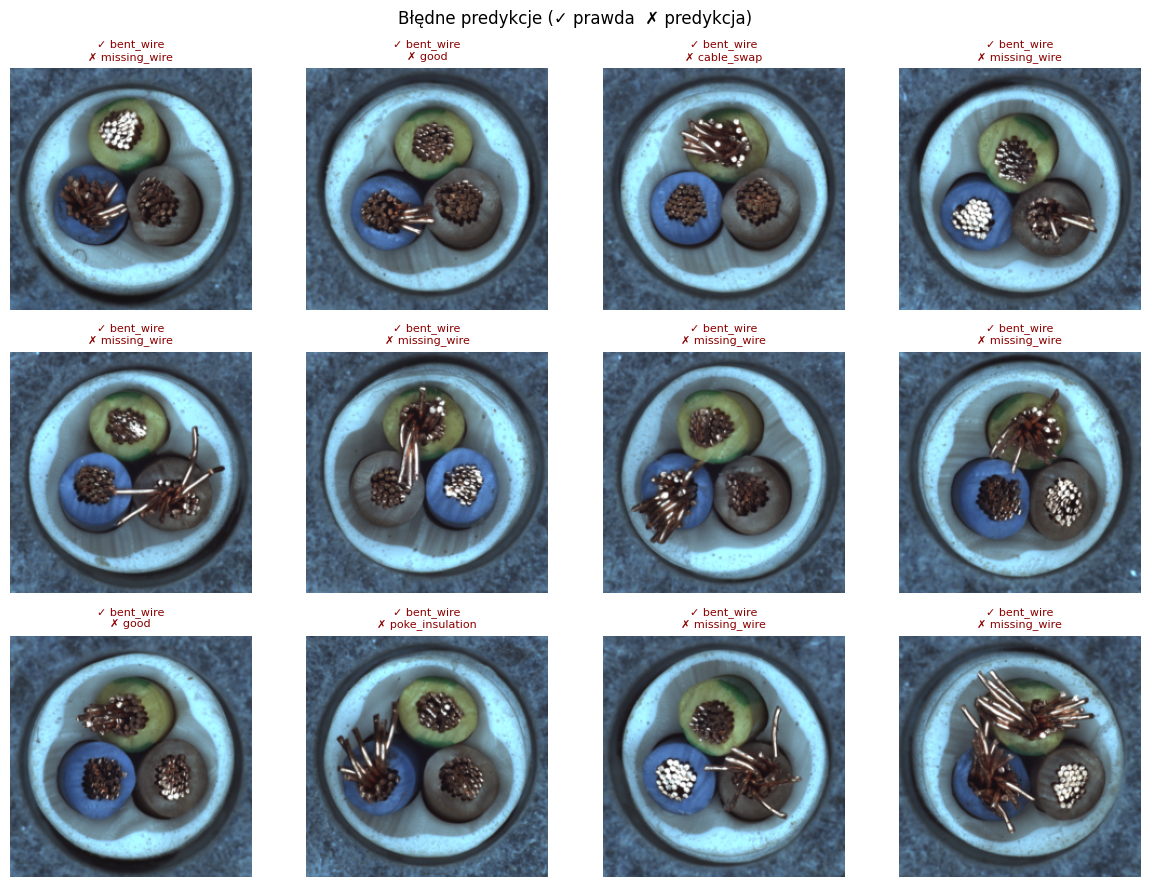

In [20]:
@torch.no_grad()
def get_errors(model, loader, max_n=12):
    model.eval()
    imgs_out, true_out, pred_out = [], [], []
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    for imgs, labels in loader:
        out   = model(imgs.to(DEVICE))
        preds = out.argmax(1).cpu()
        mask  = preds != labels
        for img, tl, pl in zip(imgs[mask], labels[mask], preds[mask]):
            show = (img * std + mean).clamp(0,1).permute(1,2,0).numpy()
            imgs_out.append(show)
            true_out.append(tl.item())
            pred_out.append(pl.item())
            if len(imgs_out) >= max_n:
                return imgs_out, true_out, pred_out
    return imgs_out, true_out, pred_out

err_imgs, err_true, err_pred = get_errors(model, test_loader)

if err_imgs:
    cols = min(4, len(err_imgs))
    rows = (len(err_imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = np.array(axes).flatten()
    for i, (img, tl, pl) in enumerate(zip(err_imgs, err_true, err_pred)):
        axes[i].imshow(img)
        axes[i].set_title(
            f'✓ {CLASS_NAMES[tl]}\n✗ {CLASS_NAMES[pl]}',
            fontsize=8, color='darkred'
        )
        axes[i].axis('off')
    for ax in axes[len(err_imgs):]:
        ax.axis('off')
    plt.suptitle('Błędne predykcje (✓ prawda  ✗ predykcja)', fontsize=12)
    plt.tight_layout()
    plt.savefig('errors.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Brak błędów — świetny wynik!')

## 11. (Opcja) Fine-tuning całej sieci

Jeśli accuracy < 70%, odmroź cały backbone i dotrenuj z LR=1e-5.

In [22]:
# Odmroź backbone
for param in model.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(model.parameters(), lr=1e-5)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode='min', factor=0.5, patience=4
)
criterion_ft = nn.CrossEntropyLoss(weight=class_weights)

best_val_loss_ft, best_state_ft = float('inf'), None
patience_ctr_ft = 0
NUM_EPOCHS_FT = 20

print('Fine-tuning (odmrożony backbone):')
print(f'{"Epoka":>6} | {"Tr Acc":>7} | {"Val Acc":>7}')

for epoch in range(1, NUM_EPOCHS_FT + 1):
    tr_l, tr_a = train_epoch(model, train_loader, optimizer_ft, criterion_ft)
    vl_l, vl_a = eval_epoch(model, val_loader, criterion_ft)
    scheduler_ft.step(vl_l)

    tag = ''
    if vl_l < best_val_loss_ft:
        best_val_loss_ft = vl_l
        best_state_ft    = copy.deepcopy(model.state_dict())
        patience_ctr_ft  = 0
        tag = ' ✓'
    else:
        patience_ctr_ft += 1

    print(f'{epoch:>6} | {tr_a*100:>6.1f}% | {vl_a*100:>6.1f}%{tag}')

    if patience_ctr_ft >= PATIENCE:
        print(f'Early stopping po epoce {epoch}.')
        break

model.load_state_dict(best_state_ft)
torch.save(model.state_dict(), 'best_model_finetuned.pth')
print('Zapisano: best_model_finetuned.pth')
print('\nUruchom sekcję 8 ponownie żeby zobaczyć zaktualizowane wyniki.')

Fine-tuning (odmrożony backbone):
 Epoka |  Tr Acc | Val Acc
     1 |   30.1% |   54.3% ✓
     2 |   27.3% |   54.3% ✓
     3 |   30.1% |   58.6% ✓
     4 |   31.2% |   60.0% ✓
     5 |   27.3% |   58.6% ✓
     6 |   28.1% |   55.7% ✓
     7 |   28.1% |   60.0% ✓
     8 |   36.7% |   61.4% ✓
     9 |   31.2% |   60.0% ✓
    10 |   28.9% |   57.1% ✓
    11 |   31.2% |   60.0% ✓
    12 |   32.4% |   58.6% ✓
    13 |   34.0% |   57.1% ✓
    14 |   30.1% |   58.6% ✓
    15 |   34.0% |   57.1% ✓
    16 |   33.2% |   60.0% ✓
    17 |   35.9% |   54.3% ✓
    18 |   35.2% |   58.6% ✓
    19 |   40.2% |   55.7% ✓
    20 |   39.5% |   57.1% ✓
Zapisano: best_model_finetuned.pth

Uruchom sekcję 8 ponownie żeby zobaczyć zaktualizowane wyniki.


## 12. Podsumowanie wyników

| Metryka | Wartość |
|---|---|
| Test Accuracy | ___% |
| F1 (macro) | ___ |
| F1 (weighted) | ___ |
| Klasa z najgorszym recall | ___ |
| Najczęstszy błąd | ___ mylone z ___ |

**Omówienie ograniczeń:**
- Bardzo mała liczba obrazów wad na klasę (kilka–kilkanaście) — model może nie uogólniać dobrze.
- Zbiór `train/` zawiera tylko klasę `good` → model uczy się wad wyłącznie z `test/`, co jest niestandardowe.
- Maski `ground_truth/` umożliwiają segmentację, ale nie są tu używane (klasyfikacja całego obrazu).
- Klasy mogą być wizualnie bardzo podobne (np. `bent_wire` vs `cable_swap`).

**Propozycje ulepszeń:**
- Augmentacja danych przy użyciu biblioteki `albumentations` (bardziej zaawansowane transformacje).
- Użycie masek `ground_truth/` do treningu modelu segmentacyjnego (np. U-Net).
- Podejście anomaly detection: wytrenuj model tylko na `good` i wykrywaj odchylenia (np. AutoEncoder, PatchCore).